# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

1. A linear model predics the target varibale by a vector of features. The prediction comes from the dot product between the feature variable and a weight vector, which is the sum of the products, making it the linear combination of these two.
2. There would be no intercept if all the varibales are included. The coefficients would be direct predictors, making it the mean of y for that variable. However, if one varible is dropped, then the intercept would be the baseline prediction, and the coefficients would be differences between predictions by categories.
3. Linear models are a regression, so the predictions are numeric values from a continuous range, which are not discrete categories, making it bad for classification.
4. Overfitting occurs when the model captures too much noise, which is often associated with including too many features. This can be evident if the model performs well on training data, but poorly on validation or test data.
5. Multi-colinearity is when one feature variable influences another feature variable, which the model can't distinguish. Two-stage least squares technique first regresses one of the feature variables on everything else to extract only the variation due to it. The first prediction then replaces the feature varibale in the original regression. This makes it so that the independent feature variables have no influece over each other, making prediction more reliable.
6. You can include transformations of x, such as logx or x^2, as a seperate feature variable to include in the regression.
7. The intercept is the prediction when all the feature varaibles are 0. The slope coefficient is the predicted change in y for one unit increase of x. For dummy with the intercept, the coefficient is a measure of difference in prediction of y between the variable and the reference or dropped variable. Without an intercept, the coefficients are the mean value of y for that category.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

data = pd.read_csv("/data/Q1_clean.csv")
data['log_price'] = np.log(data['Price'])

Neighbourhood 
Manhattan        183.664286
Staten Island    146.166667
Brooklyn         127.747378
Queens            96.857233
Bronx             75.276498
Name: Price, dtype: float64


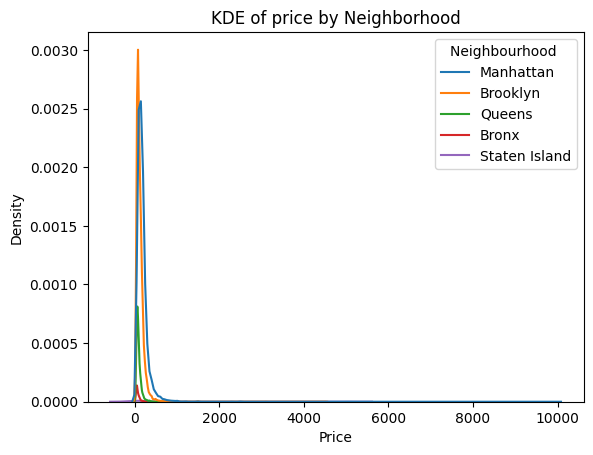

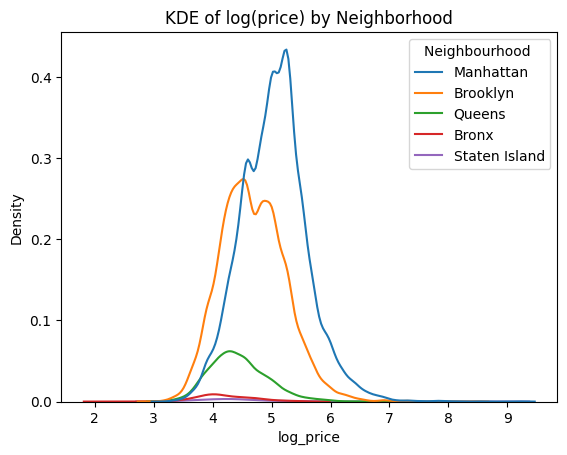

R-squared:  0.04631389606035197
        variable  coefficient
0          Bronx    75.276498
1       Brooklyn   127.747378
2      Manhattan   183.664286
3         Queens    96.857233
4  Staten Island   146.166667
R-squared:  0.04631389606035197
Intercept:  75.27649769585331
        variable  coefficient
0       Brooklyn    52.470881
1      Manhattan   108.387789
2         Queens    21.580735
3  Staten Island    70.890169
#Have to drop one category in the creation of the dummies. The intercept
is the average of the dropped category. The coefficients are the difference 
between the average of that category and the dropped category, so that adding 
the coefficient and intercept produces the average of the variable category.


In [4]:
#1
print(data.groupby('Neighbourhood ')['Price'].mean().sort_values(ascending=False))
#Manhattan is most expensive on average
sns.kdeplot(data=data, x="Price", hue="Neighbourhood ")
plt.title('KDE of price by Neighborhood')
plt.show()

sns.kdeplot(data=data, x=('log_price'), hue="Neighbourhood ")
plt.title('KDE of log(price) by Neighborhood')
plt.show()

#2
dummies = pd.get_dummies(data['Neighbourhood '], drop_first=False)

model = LinearRegression(fit_intercept=False).fit(dummies, data['Price'])
results = pd.DataFrame({'variable': model.feature_names_in_, 'coefficient': model.coef_})
print('R-squared: ', model.score(dummies, data['Price']))
print(results)
#The coefficients and means are the same. The coefficient is the predicted price given the categorical variable, ei the estimated price of an appartment if it were in Manhattan.

#3
dummies2 = pd.get_dummies(data['Neighbourhood '], drop_first=True)
model2 = LinearRegression(fit_intercept=True).fit(dummies2, data['Price'])
results2 = pd.DataFrame({'variable': model2.feature_names_in_, 'coefficient': model2.coef_})
print('R-squared: ', model2.score(dummies2, data['Price']))
print('Intercept: ', model2.intercept_)
print(results2)
print("""#Have to drop one category in the creation of the dummies. The intercept
is the average of the dropped category. The coefficients are the difference
between the average of that category and the dropped category, so that adding
the coefficient and intercept produces the average of the variable category.""")

In [5]:
#4
X = data[['Review Scores Rating', 'Neighbourhood ']]
y = data['Price']
X = pd.get_dummies(X)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 65)
model3 = LinearRegression(fit_intercept=False).fit(X_train, y_train)
print('R-squared: ', model3.score(X_test, y_test))
print('RMSE: ', np.sqrt(np.mean((model3.predict(X_test) - y_test)**2)))
print('Review Scores Rating coefficient: ', model3.coef_[0])
results3 = pd.DataFrame({'variable': model3.feature_names_in_, 'coefficient': model3.coef_})
print(results3)
print("The most expensive property kind is one with a high rating in Manhattan \n")

#5
X2 = data[['Review Scores Rating', 'Neighbourhood ', 'Property Type']]
y2 = data['Price']
X2 = pd.get_dummies(X2)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y2, test_size=0.2, random_state = 66)
model4 = LinearRegression(fit_intercept=False).fit(X2_train, y2_train)
print('R-squared: ', model4.score(X2_test, y2_test))
print('RMSE: ', np.sqrt(np.mean((model4.predict(X2_test) - y2_test)**2)))
print('Review Scores Rating coefficient: ', model4.coef_[0])
results4 = pd.DataFrame({'variable': model4.feature_names_in_, 'coefficient': model4.coef_})
print(results4)
print("A condominium in Manhattan with a perfect rating would be the most expensive type of rental")

#6
print("""\n The coefficient on Review Scores Rating in part 4 was the effect of the rating,
holding neighborhood constant. The coefficient in part 5 is the ffect of the rating holding
neighborhood and property type constant. It changes between the two because an additional variable
is controlled which had its contribution previously attributed to the included varibales.""")

R-squared:  0.029117109332052915
RMSE:  194.0474943299375
Review Scores Rating coefficient:  1.0160958637516389
                       variable  coefficient
0          Review Scores Rating     1.016096
1          Neighbourhood _Bronx   -17.990354
2       Neighbourhood _Brooklyn    33.192821
3      Neighbourhood _Manhattan    89.938768
4         Neighbourhood _Queens     3.694639
5  Neighbourhood _Staten Island    65.146603
The most expensive property kind is one with a high rating in Manhattan 

R-squared:  0.03158182898017603
RMSE:  199.54153286983842
Review Scores Rating coefficient:  1.0793078991298146
                         variable  coefficient
0            Review Scores Rating     1.079308
1            Neighbourhood _Bronx   -36.328523
2         Neighbourhood _Brooklyn    22.673953
3        Neighbourhood _Manhattan    83.515702
4           Neighbourhood _Queens   -10.418101
5    Neighbourhood _Staten Island    41.641122
6         Property Type_Apartment    -1.477127
7   Propert

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

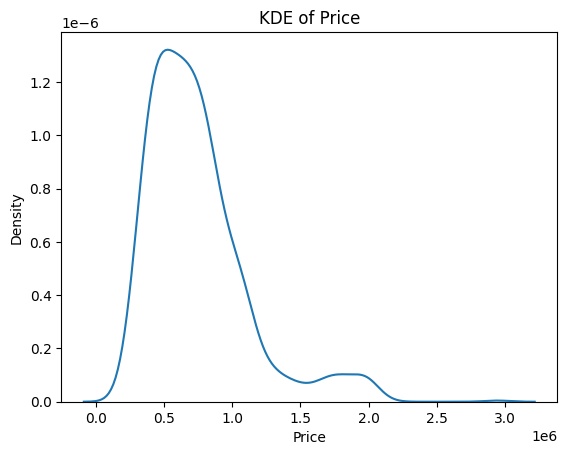

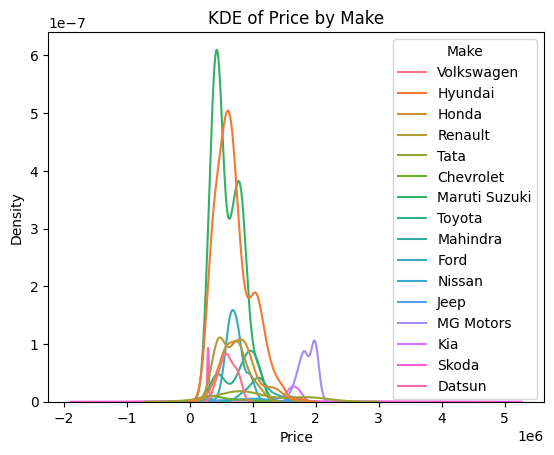

array([2017, 2016, 2019, 2012, 2021, 2020, 2013, 2022, 2018, 2014, 2011,
       2015])

In [6]:
#1
cars = pd.read_csv("/data/cars_hw.csv")
cars['age'] = max(cars['Make_Year']) - cars['Make_Year']

#2
cars.groupby('Make')['Price'].describe()
sns.kdeplot(data=cars, x="Price")
plt.title('KDE of Price')
plt.show()
sns.kdeplot(data=cars, x="Price", hue = 'Make')
plt.title('KDE of Price by Make')
plt.show()
cars['Make_Year'].unique()

In [7]:
#3
X = cars[['Mileage_Run', 'Seating_Capacity', 'age', 'Color', 'Body_Type', 'Make', 'Fuel_Type', 'Transmission', 'Transmission_Type']]
y = cars['Price']
X = pd.get_dummies(X)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 67)

#4
X_num = X[['Mileage_Run', 'Seating_Capacity', 'age']]
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(X_num,y, test_size=0.2, random_state = 68)
model_num = LinearRegression(fit_intercept=False).fit(X_train_num, y_train_num)
print('Numerical model: \n', 'R-squared: ', model_num.score(X_test_num, y_test_num))
print('RMSE: ', np.sqrt(np.mean((model_num.predict(X_test_num) - y_test_num)**2)))

X_cat = X.drop(['Mileage_Run', 'Seating_Capacity', 'age'], axis=1)
X_cat = pd.get_dummies(X)
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat,y, test_size=0.2, random_state = 69)
model_cat = LinearRegression(fit_intercept=False).fit(X_train_cat, y_train_cat)
print('\n Categorical model: \n', 'R-squared: ', model_cat.score(X_test_cat, y_test_cat))
print('RMSE: ', np.sqrt(np.mean((model_cat.predict(X_test_cat) - y_test_cat)**2)))

print('The categorical model has a lot higher R-squared and a lot lower RMSE, signifying that it performed a lot better.')

model_comb = LinearRegression(fit_intercept=False).fit(X_train, y_train)
print('\n Combined model: \n', 'R-squared: ', model_comb.score(X_test, y_test))
print('RMSE: ', np.sqrt(np.mean((model_comb.predict(X_test) - y_test)**2)))

print("""
The combined model has a 0.045 lower R-squared and a 14,400 lower RMSE than the categorical model, meaning
the results are mixed as to which is truly better. This could be a result of many outliers in the data or the random sampling.""")

Numerical model: 
 R-squared:  0.23631041282302523
RMSE:  346239.43043277133

 Categorical model: 
 R-squared:  0.8541297814575753
RMSE:  150717.10105924826
The categorical model has a lot higher R-squared and a lot lower RMSE, signifying that it performed a lot better.

 Combined model: 
 R-squared:  0.8089060146873966
RMSE:  136287.9870691301

The combined model has a 0.045 lower R-squared and a 14,400 lower RMSE than the categorical model, meaning
the results are mixed as to which is truly better. This could be a result of many outliers in the data or the random sampling.


In [8]:
#5
from sklearn.preprocessing import PolynomialFeatures
expander2 = PolynomialFeatures(degree=2,include_bias=False)
X_train_2 = expander2.fit_transform(X_train)
X_test_2 = expander2.fit_transform(X_test)
model_2 = LinearRegression(fit_intercept=False).fit(X_train_2, y_train)
print('d=2 model: \n', 'R-squared: ', model_2.score(X_test_2, y_test))
print('RMSE: ', np.sqrt(np.mean((model_2.predict(X_test_2) - y_test)**2)), '\n')

expander3 = PolynomialFeatures(degree=3,include_bias=False)
X_train_3 = expander3.fit_transform(X_train)
X_test_3 = expander3.fit_transform(X_test)
model_3 = LinearRegression(fit_intercept=False).fit(X_train_3, y_train)
print('d=3 model: \n', 'R-squared: ', model_3.score(X_test_3, y_test))
print('RMSE: ', np.sqrt(np.mean((model_3.predict(X_test_3) - y_test)**2)), '\n')

expander4 = PolynomialFeatures(degree=4,include_bias=False)
X_train_4 = expander4.fit_transform(X_train)
X_test_4 = expander4.fit_transform(X_test)
model_4 = LinearRegression(fit_intercept=False).fit(X_train_4, y_train)
print('d=4 model: \n', 'R-squared: ', model_4.score(X_test_4, y_test))
print('RMSE: ', np.sqrt(np.mean((model_4.predict(X_test_4) - y_test)**2)), '\n')

print("""R-squared goes negative at 3rd degree. Continued higher degrees further decrease R-squared
and increases RMSE. The 2nd degree model is the best expansion, but is still worse than the categorical
model from part 4 with a .23 lower r-squared, and 41,000 higher RMSE.""")

d=2 model: 
 R-squared:  0.6239133195433451
RMSE:  191195.66647434895 

d=3 model: 
 R-squared:  -0.5785672457439763
RMSE:  391710.8596007176 

d=4 model: 
 R-squared:  -2.984520003804251
RMSE:  622331.9158112033 



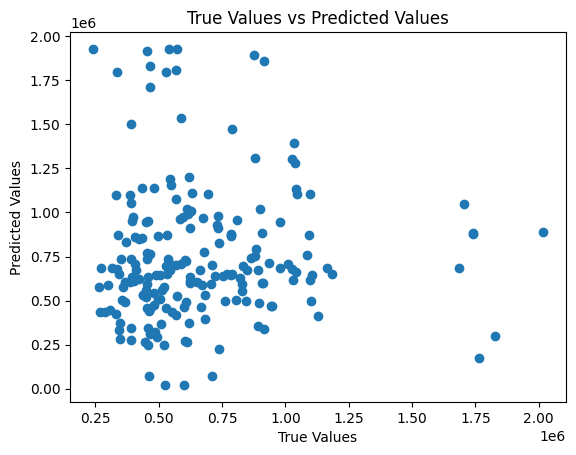


 The majority of the values line up extremely roughly along the diagonal, 
but the spread is wide and there are several outliers.


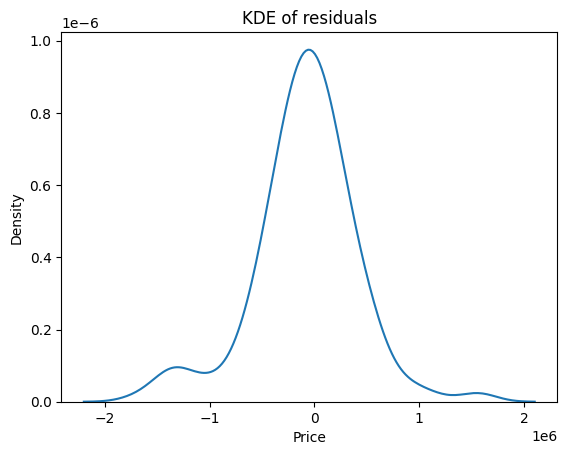

The residuals are roughly bell shaped around zero.
The model is not very accurate in its predictions, but it is relatively precise
with the error centered around zero.


In [27]:
#6
y_prediction = model_cat.predict(X_test_cat)
plt.scatter(x = y_test,y = y_prediction)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True Values vs Predicted Values')
plt.show()

print('\n', """The majority of the values line up extremely roughly along the diagonal,
but the spread is wide and there are several outliers.""")

residuals = y_test - y_prediction
sns.kdeplot(residuals)
plt.title('KDE of residuals')
plt.show()

print('The residuals are roughly bell shaped around zero.')

print("""The model is not very accurate in its predictions, but it is relatively precise
with the error centered around zero.""")

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

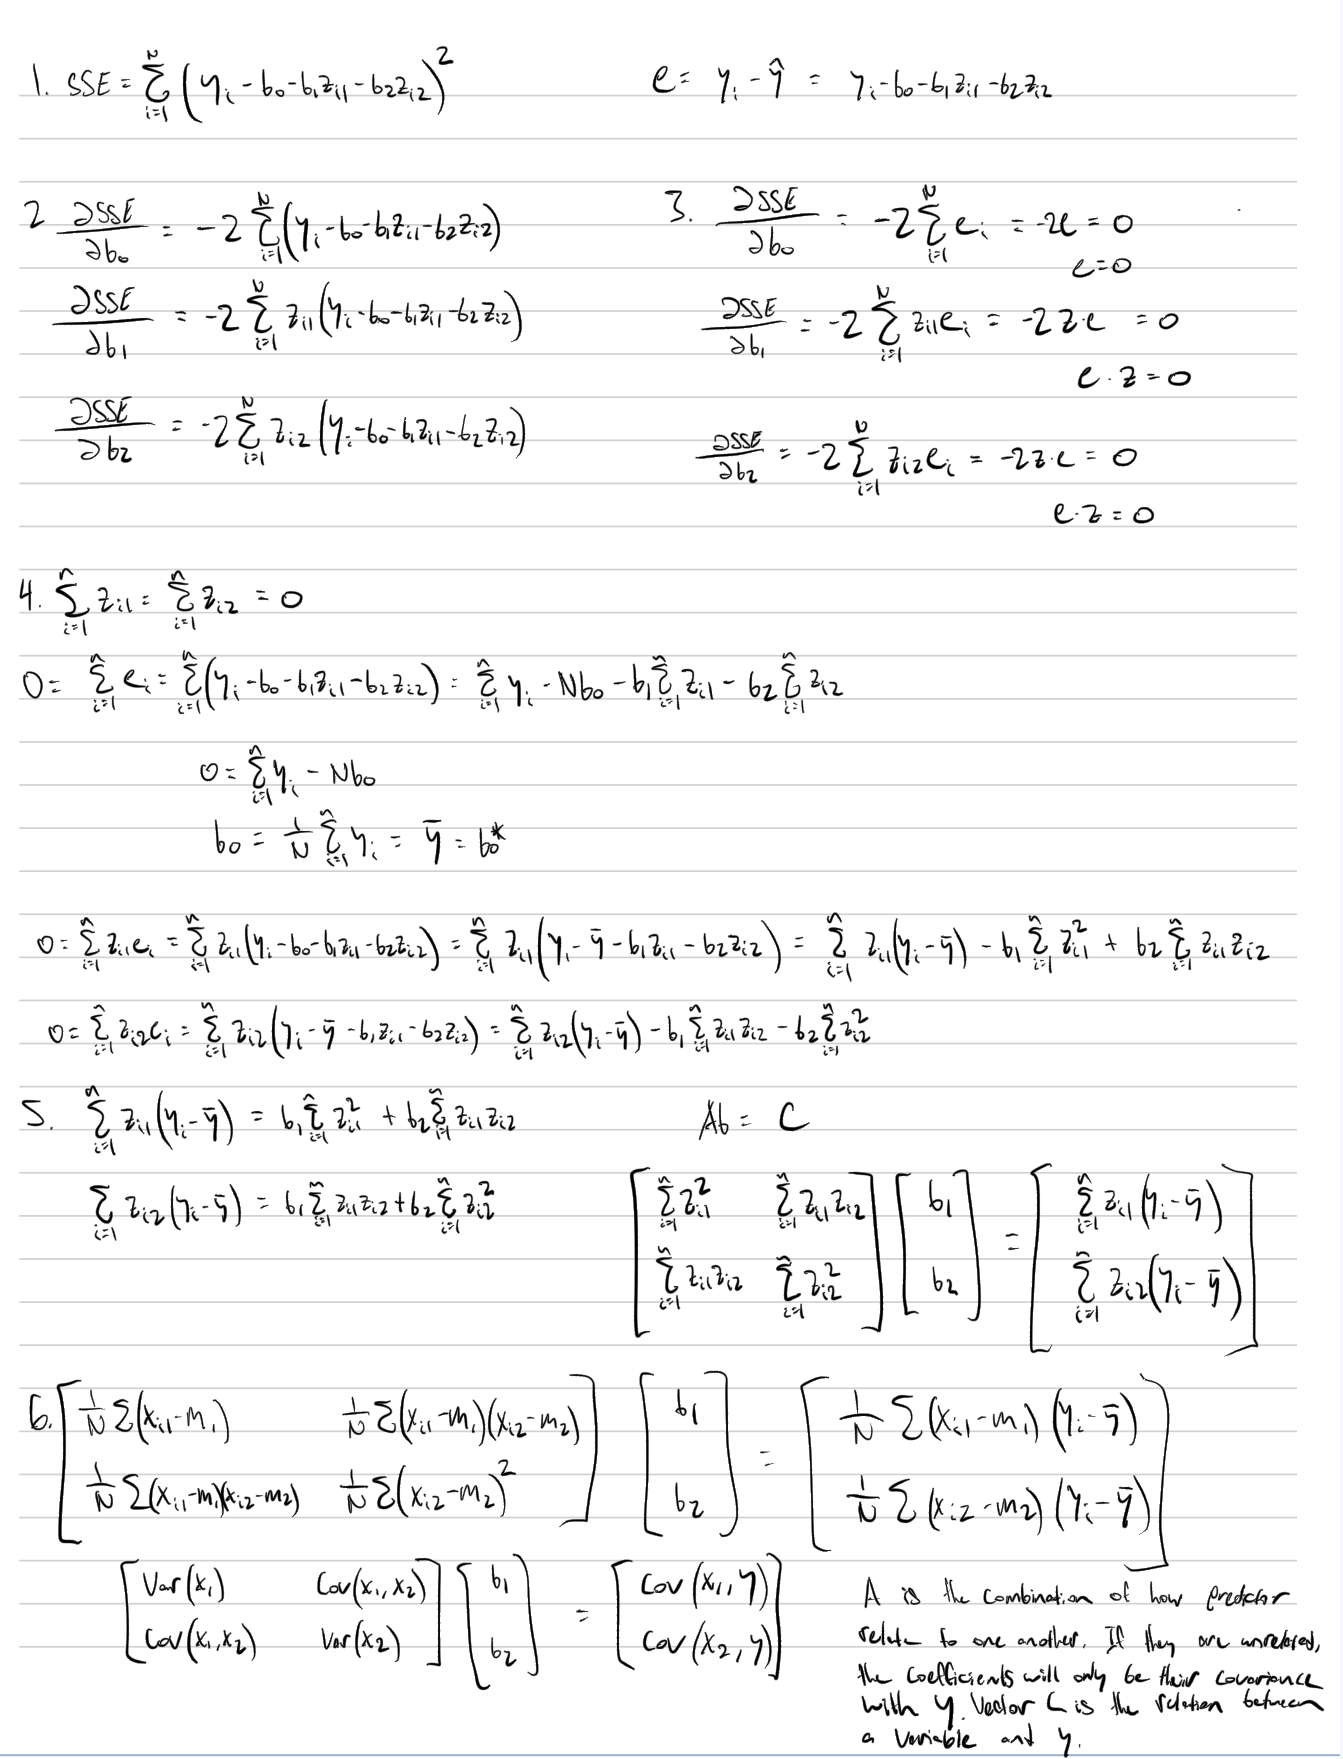